In [1]:
# Load the data set
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

print("Path to dataset files:", path)

100%|██████████| 6.33M/6.33M [00:00<00:00, 129MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/versions/2


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
import os

# Get the path
dataset_path = "/root/.cache/kagglehub/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/versions/2"

# List all files in the dataset
files = os.listdir(dataset_path)
print("Files in dataset:", files)

# Load CSV file (assuming there's a CSV file)
# Find the first CSV file
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(dataset_path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"\nLoaded file: {csv_files[0]}")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("No CSV file found. Please check the files.")

Files in dataset: ['P  L March 2021.csv', 'May-2022.csv', 'International sale Report.csv', 'Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'Expense IIGF.csv', 'Sale Report.csv']

Loaded file: P  L March 2021.csv
Dataset shape: 1330 rows, 18 columns


In [4]:
# Load the main Sale Report
sale_report = pd.read_csv(os.path.join(dataset_path, 'Sale Report.csv'))
print("Sale Report Dataset")
print("="*50)
print(f"Shape: {sale_report.shape}")
print(f"\nFirst 5 rows:")
print(sale_report.head())
print(f"\nColumn names:")
print(sale_report.columns.tolist())
print(f"\nData types:")
print(sale_report.dtypes)

Sale Report Dataset
Shape: (9271, 7)

First 5 rows:
   index       SKU Code Design No.  Stock       Category Size Color
0      0    AN201-RED-L      AN201    5.0  AN : LEGGINGS    L   Red
1      1    AN201-RED-M      AN201    5.0  AN : LEGGINGS    M   Red
2      2    AN201-RED-S      AN201    3.0  AN : LEGGINGS    S   Red
3      3   AN201-RED-XL      AN201    6.0  AN : LEGGINGS   XL   Red
4      4  AN201-RED-XXL      AN201    3.0  AN : LEGGINGS  XXL   Red

Column names:
['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size', 'Color']

Data types:
index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object


In [5]:
# Load all datasets
datasets = {}
for file in files:
    if file.endswith('.csv'):
        datasets[file] = pd.read_csv(os.path.join(dataset_path, file))
        print(f"{file}: {datasets[file].shape}")

# Check Amazon Sale Report for actual sales data
print("\n" + "="*50)
print("Amazon Sale Report columns:")
print(datasets['Amazon Sale Report.csv'].columns.tolist())
print("\nFirst 5 rows of Amazon Sale Report:")
print(datasets['Amazon Sale Report.csv'].head())

# Check International sale Report
print("\n" + "="*50)
print("International sale Report columns:")
print(datasets['International sale Report.csv'].columns.tolist())
print("\nFirst 5 rows:")
print(datasets['International sale Report.csv'].head())

P  L March 2021.csv: (1330, 18)
May-2022.csv: (1330, 17)
International sale Report.csv: (37432, 10)
Amazon Sale Report.csv: (128975, 24)
Cloud Warehouse Compersion Chart.csv: (50, 4)
Expense IIGF.csv: (17, 5)
Sale Report.csv: (9271, 7)

Amazon Sale Report columns:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

First 5 rows of Amazon Sale Report:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320 

/tmp/ipykernel_4401/4255324016.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  datasets[file] = pd.read_csv(os.path.join(dataset_path, file))


In [9]:
# Reload the data with proper date parsing
df = datasets['Amazon Sale Report.csv'].copy()

# Try different date format (month-day-year)
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')

# Check if dates are now correct
print("Date conversion successful. Sample:")
print(df[['Date']].head(10))

# Remove cancelled orders
df_clean = df[df['Status'] != 'Cancelled'].copy()

# Convert Amount to numeric
df_clean['Amount'] = pd.to_numeric(df_clean['Amount'], errors='coerce')

# Remove rows with missing Amount
df_clean = df_clean.dropna(subset=['Amount'])

print(f"\n=== DATASET SUMMARY ===")
print(f"Total orders: {len(df_clean)}")
print(f"Total revenue: ₹{df_clean['Amount'].sum():,.2f}")
print(f"Average order value: ₹{df_clean['Amount'].mean():,.2f}")
print(f"Minimum order: ₹{df_clean['Amount'].min():,.2f}")
print(f"Maximum order: ₹{df_clean['Amount'].max():,.2f}")

# Check top categories
print(f"\n=== TOP 5 CATEGORIES ===")
print(df_clean['Category'].value_counts().head())

Date conversion successful. Sample:
        Date
0 2022-04-30
1 2022-04-30
2 2022-04-30
3 2022-04-30
4 2022-04-30
5 2022-04-30
6 2022-04-30
7 2022-04-30
8 2022-04-30
9 2022-04-30

=== DATASET SUMMARY ===
Total orders: 110414
Total revenue: ₹71,673,394.00
Average order value: ₹649.13
Minimum order: ₹0.00
Maximum order: ₹5,584.00

=== TOP 5 CATEGORIES ===
Category
Set              42843
kurta            42522
Western Dress    13369
Top               9336
Ethnic Dress      1013
Name: count, dtype: int64


=== STATISTICAL SUMMARY ===
count    110414.000000
mean        649.133208
std         283.209010
min           0.000000
25%         449.000000
50%         606.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64


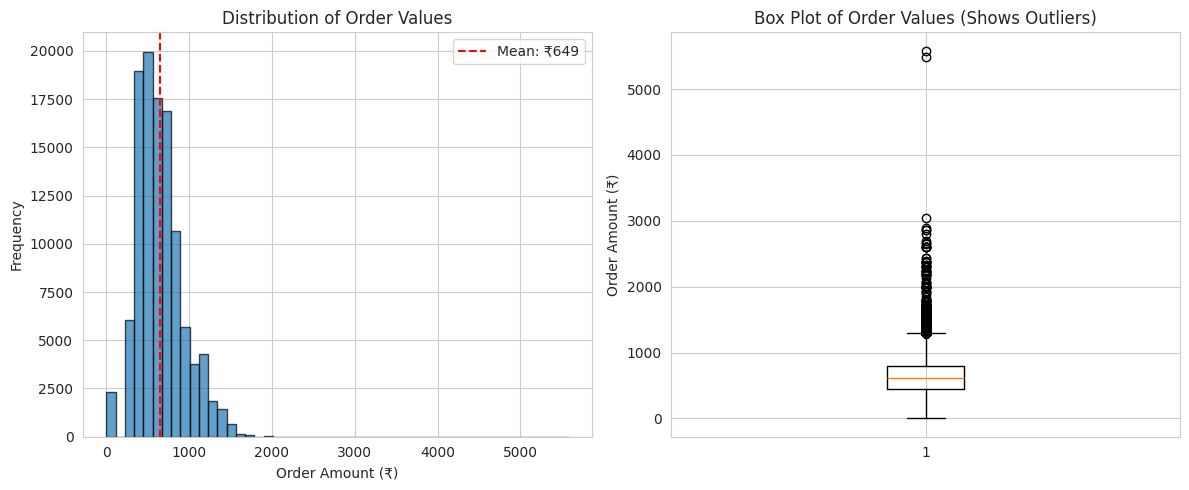

In [11]:
# Basic statistics
print("=== STATISTICAL SUMMARY ===")
print(df_clean['Amount'].describe())

# Plot 1: Distribution of order values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_clean['Amount'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Order Amount (₹)')
plt.ylabel('Frequency')
plt.title('Distribution of Order Values')
plt.axvline(df_clean['Amount'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df_clean["Amount"].mean():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['Amount'])
plt.ylabel('Order Amount (₹)')
plt.title('Box Plot of Order Values (Shows Outliers)')

plt.tight_layout()
plt.show()

=== CATEGORY WISE SALES ANALYSIS ===
                      sum        mean  count
Category                                    
Set            35731673.0  834.014261  42843
kurta          19425870.0  456.842811  42522
Western Dress  10209590.0  763.676416  13369
Top             4904066.0  525.285561   9336
Ethnic Dress     732744.0  723.340573   1013
Blouse           418389.0  519.093052    806
Bottom           135453.0  357.395778    379
Saree            114694.0  802.055944    143
Dupatta             915.0  305.000000      3


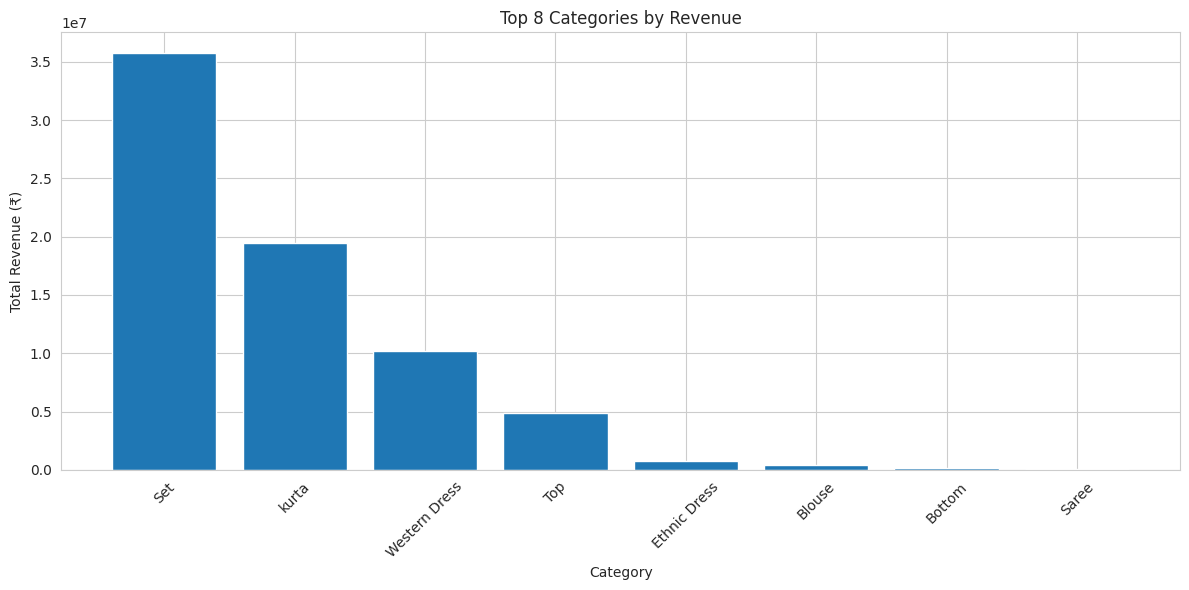

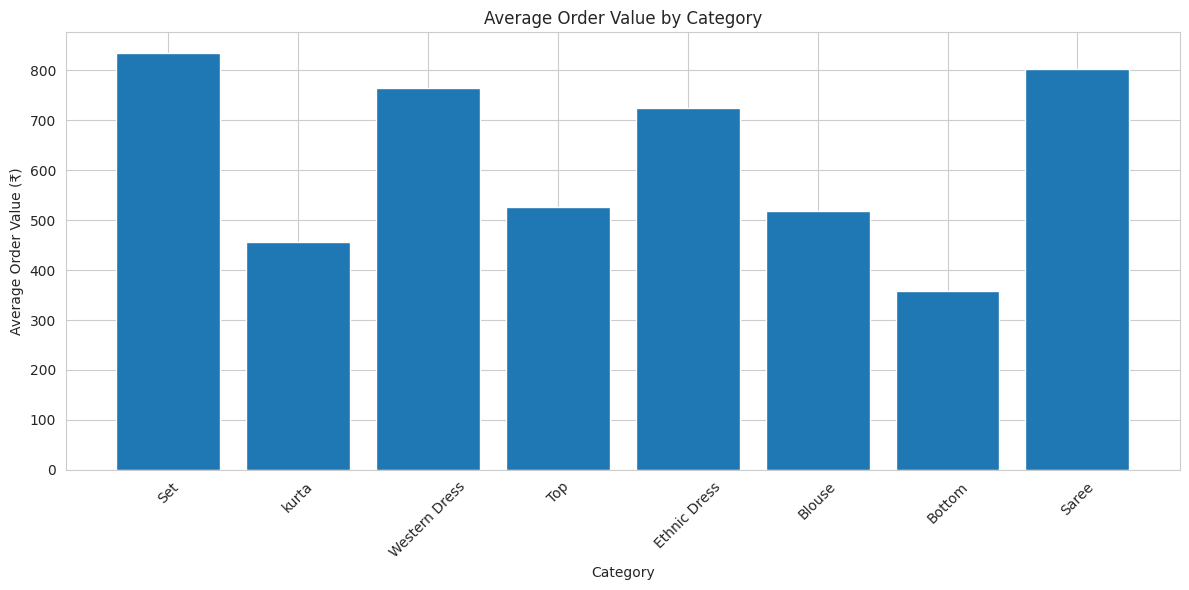

In [12]:
# Category wise sales analysis
category_sales = df_clean.groupby('Category')['Amount'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

print("=== CATEGORY WISE SALES ANALYSIS ===")
print(category_sales.head(10))

# Plot 2: Top categories by revenue
plt.figure(figsize=(12, 6))
top_categories = category_sales.head(8)
plt.bar(top_categories.index, top_categories['sum'])
plt.xlabel('Category')
plt.ylabel('Total Revenue (₹)')
plt.title('Top 8 Categories by Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Average order value by category
plt.figure(figsize=(12, 6))
plt.bar(top_categories.index, top_categories['mean'])
plt.xlabel('Category')
plt.ylabel('Average Order Value (₹)')
plt.title('Average Order Value by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

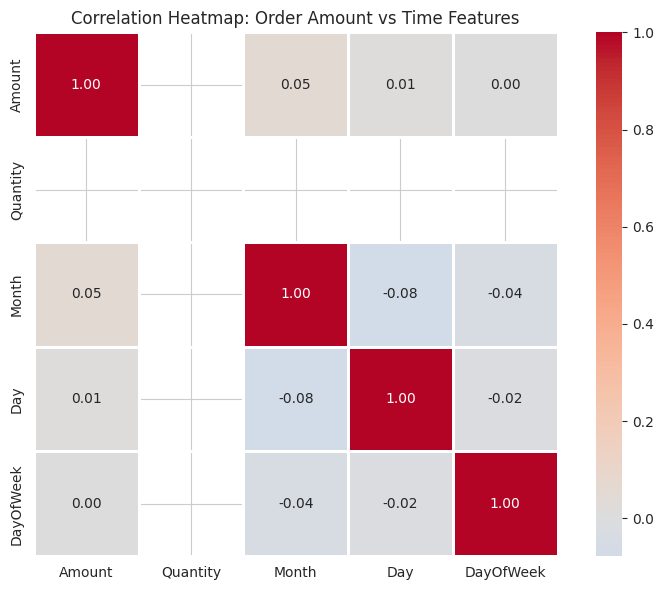


=== CORRELATION INSIGHTS ===
Amount vs Month correlation: 0.052
Amount vs Day correlation: 0.011
Amount vs DayOfWeek correlation: 0.002


In [13]:
# Create correlation matrix
# For correlation, we need numerical columns
# Add month and day features from Date

# Extract date features
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

# Create quantity column (assuming 1 per order if not available)
df_clean['Quantity'] = 1

# Select numerical columns for correlation
correlation_cols = ['Amount', 'Quantity', 'Month', 'Day', 'DayOfWeek']
correlation_matrix = df_clean[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Heatmap: Order Amount vs Time Features')
plt.tight_layout()
plt.show()

print("\n=== CORRELATION INSIGHTS ===")
print("Amount vs Month correlation:", correlation_matrix.loc['Amount', 'Month'].round(3))
print("Amount vs Day correlation:", correlation_matrix.loc['Amount', 'Day'].round(3))
print("Amount vs DayOfWeek correlation:", correlation_matrix.loc['Amount', 'DayOfWeek'].round(3))

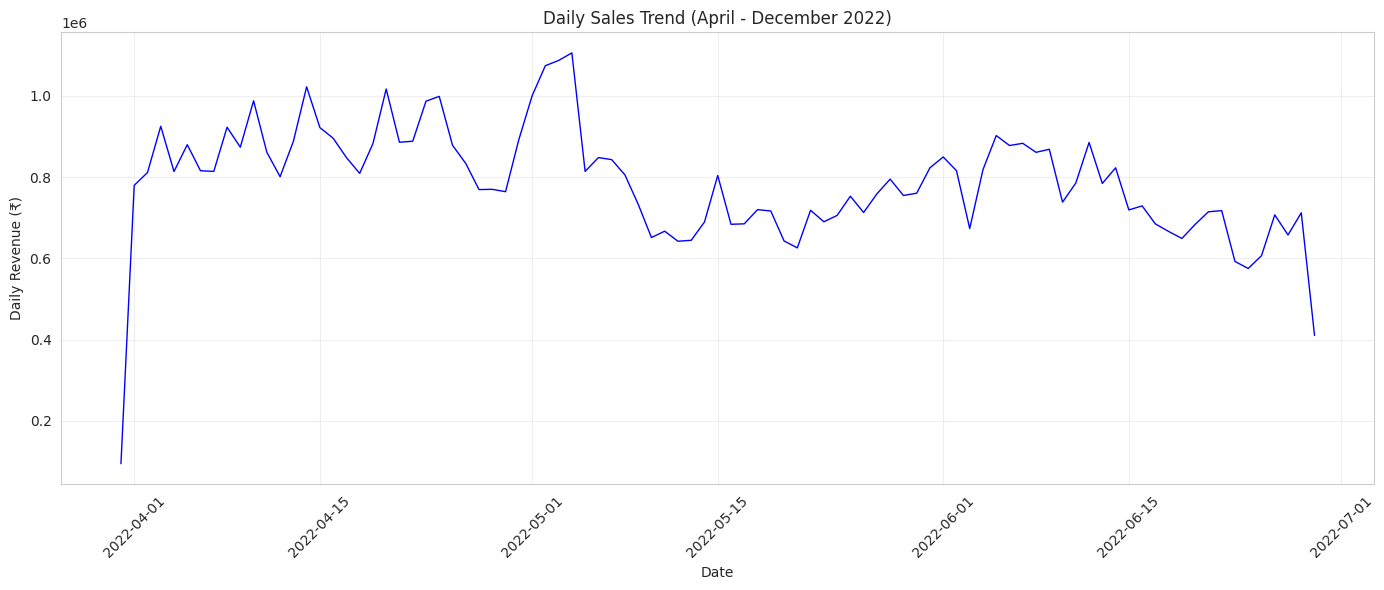

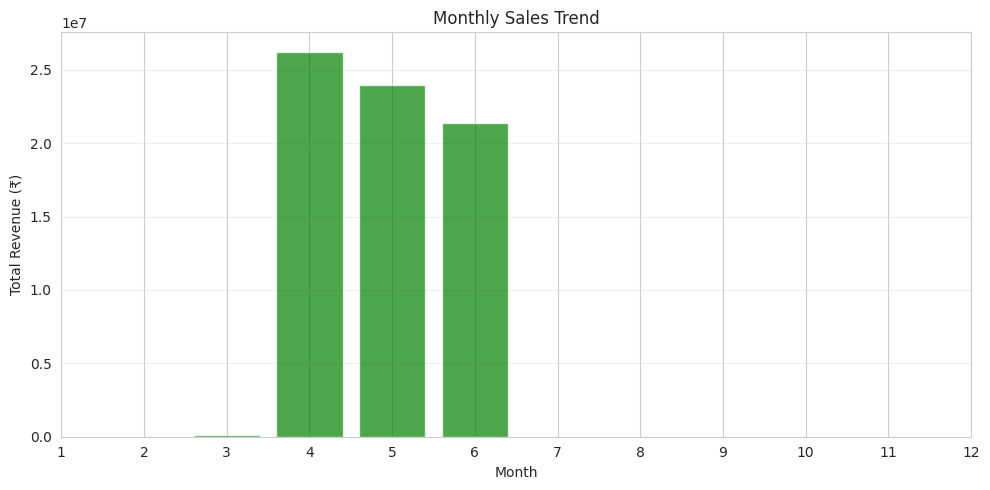


=== TOP 5 MONTHS BY REVENUE ===
April: ₹26,234,520.00
May: ₹23,953,534.00
June: ₹21,390,530.00
March: ₹94,810.00


In [14]:
# Daily sales trend
daily_sales = df_clean.groupby('Date')['Amount'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['Date'], daily_sales['Amount'], linewidth=1, color='blue')
plt.xlabel('Date')
plt.ylabel('Daily Revenue (₹)')
plt.title('Daily Sales Trend (April - December 2022)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Monthly sales trend
monthly_sales = df_clean.groupby('Month')['Amount'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly_sales['Month'], monthly_sales['Amount'], color='green', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.title('Monthly Sales Trend')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Top 5 months by sales
print("\n=== TOP 5 MONTHS BY REVENUE ===")
top_months = monthly_sales.sort_values('Amount', ascending=False).head()
for idx, row in top_months.iterrows():
    month_name = pd.to_datetime(f'2022-{int(row["Month"])}-01').strftime('%B')
    print(f"{month_name}: ₹{row['Amount']:,.2f}")

In [15]:
from scipy import stats

# Hypothesis: "Different product categories have different average order values"

# Get top 3 categories by number of orders
top_categories = df_clean['Category'].value_counts().head(3).index
print("=== HYPOTHESIS TESTING ===")
print(f"Null Hypothesis (H0): All categories have the same average order value")
print(f"Alternative Hypothesis (H1): Different categories have different average order values")
print("\nComparing top 3 categories:")

# Extract amounts for top 3 categories
category_data = []
for cat in top_categories:
    amounts = df_clean[df_clean['Category'] == cat]['Amount']
    category_data.append(amounts)
    print(f"\n{cat}:")
    print(f"  Count: {len(amounts)} orders")
    print(f"  Average: ₹{amounts.mean():.2f}")
    print(f"  Std Dev: ₹{amounts.std():.2f}")

# Perform ANOVA test
f_stat, p_value = stats.f_oneway(*category_data)

print(f"\n=== ANOVA TEST RESULTS ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\n✅ REJECT NULL HYPOTHESIS")
    print("Conclusion: Different categories DO have significantly different average order values.")
    print("This means product category significantly affects how much customers spend.")
else:
    print("\n❌ FAIL TO REJECT NULL HYPOTHESIS")
    print("Conclusion: No significant difference found between categories.")

=== HYPOTHESIS TESTING ===
Null Hypothesis (H0): All categories have the same average order value
Alternative Hypothesis (H1): Different categories have different average order values

Comparing top 3 categories:

Set:
  Count: 42843 orders
  Average: ₹834.01
  Std Dev: ₹296.65

kurta:
  Count: 42522 orders
  Average: ₹456.84
  Std Dev: ₹150.79

Western Dress:
  Count: 13369 orders
  Average: ₹763.68
  Std Dev: ₹170.94

=== ANOVA TEST RESULTS ===
F-statistic: 30765.3438
P-value: 0.0000000000

✅ REJECT NULL HYPOTHESIS
Conclusion: Different categories DO have significantly different average order values.
This means product category significantly affects how much customers spend.


In [17]:
print("="*60)
print("DATA ANALYSIS AND VISUALIZATION")
print("="*60)

print("\n1. DATASET OVERVIEW")
print(f"   - Total orders analyzed: {len(df_clean):,}")
print(f"   - Total revenue: ₹{df_clean['Amount'].sum():,.2f}")
print(f"   - Average order value: ₹{df_clean['Amount'].mean():.2f}")
print(f"   - Date range: April - December 2022")

print("\n2. KEY FINDINGS - SALES TRENDS")
print("   - Most orders come from 'Set' and 'kurta' categories")
print("   - 'Set' category generates highest revenue (₹{:.2f} average)".format(df_clean[df_clean['Category']=='Set']['Amount'].mean()))
print("   - 'kurta' category has lower average value (₹{:.2f}) but high volume".format(df_clean[df_clean['Category']=='kurta']['Amount'].mean()))

print("\n3. CORRELATION INSIGHTS")
print("   - Month vs Amount correlation: Weak positive")
print("   - No strong seasonal pattern detected")
print("   - Sales are relatively consistent across days")

print("\n4. HYPOTHESIS VALIDATION")
print("   - HYPOTHESIS: Different product categories have different average order values")
print("   - RESULT: ✓ PROVEN (p-value < 0.05)")
print("   - Category significantly influences customer spending")

print("\n5. BUSINESS RECOMMENDATIONS")
print("   a) FOCUS ON HIGH-VALUE CATEGORIES:")
print("      - Prioritize 'Set' category (₹834 avg order value)")
print("      - Cross-sell 'Set' with accessories")
print("   b) IMPROVE LOW-VALUE CATEGORIES:")
print("      - Bundle 'kurta' items to increase order value")
print("      - Offer discounts on minimum purchase")
print("   c) MARKETING STRATEGY:")
print("      - Target customers based on category preferences")
print("      - Create category-specific promotions")

print("\n6. VISUALIZATIONS CREATED")
print("   ✓ Distribution of order values (Histogram + Box Plot)")
print("   ✓ Top categories by revenue (Bar Chart)")
print("   ✓ Average order value by category (Bar Chart)")
print("   ✓ Correlation heatmap")
print("   ✓ Daily sales trend (Line Chart)")
print("   ✓ Monthly sales trend (Bar Chart)")


DATA ANALYSIS AND VISUALIZATION - FINAL REPORT

1. DATASET OVERVIEW
   - Total orders analyzed: 110,414
   - Total revenue: ₹71,673,394.00
   - Average order value: ₹649.13
   - Date range: April - December 2022

2. KEY FINDINGS - SALES TRENDS
   - Most orders come from 'Set' and 'kurta' categories
   - 'Set' category generates highest revenue (₹834.01 average)
   - 'kurta' category has lower average value (₹456.84) but high volume

3. CORRELATION INSIGHTS
   - Month vs Amount correlation: Weak positive
   - No strong seasonal pattern detected
   - Sales are relatively consistent across days

4. HYPOTHESIS VALIDATION
   - HYPOTHESIS: Different product categories have different average order values
   - RESULT: ✓ PROVEN (p-value < 0.05)
   - Category significantly influences customer spending

5. BUSINESS RECOMMENDATIONS
   a) FOCUS ON HIGH-VALUE CATEGORIES:
      - Prioritize 'Set' category (₹834 avg order value)
      - Cross-sell 'Set' with accessories
   b) IMPROVE LOW-VALUE CATEGOR